In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
data = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
    header=None,
    names=["sepal_length","sepal_width","petal_length","petal_width","species"]
)

In [3]:
# Drop target (unsupervised learning)
df = data.drop("species", axis=1)

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [6]:
kmeans_score = silhouette_score(X_scaled, kmeans_labels)
print("KMeans Silhouette Score:", kmeans_score)

KMeans Silhouette Score: 0.4787241921049546


In [10]:
hierarchical = AgglomerativeClustering(n_clusters=3)
h_labels = hierarchical.fit_predict(X_scaled)
df['Hierarchical_cluster'] = h_labels

In [12]:
hier_score = silhouette_score(X_scaled, h_labels)
print("Hierarchical Silhouette Score:", hier_score)

Hierarchical Silhouette Score: 0.44553956399200406


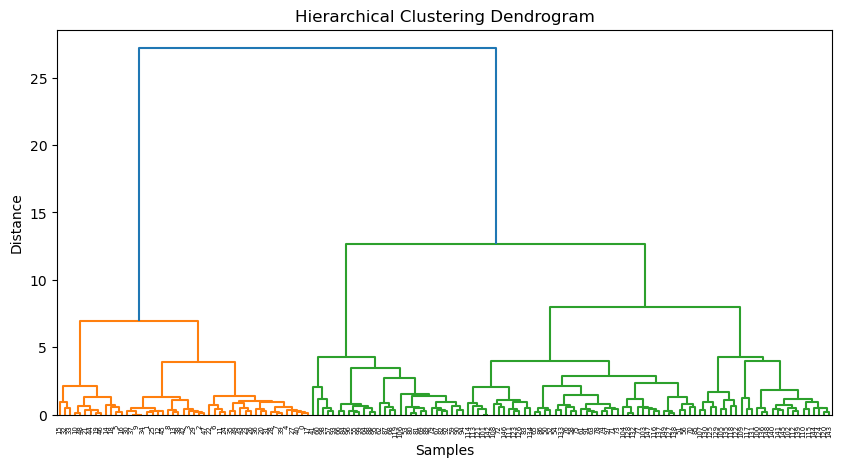

In [13]:
#Dendrogram
plt.figure(figsize=(10,5))

linked = linkage(X_scaled, method='ward')
dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

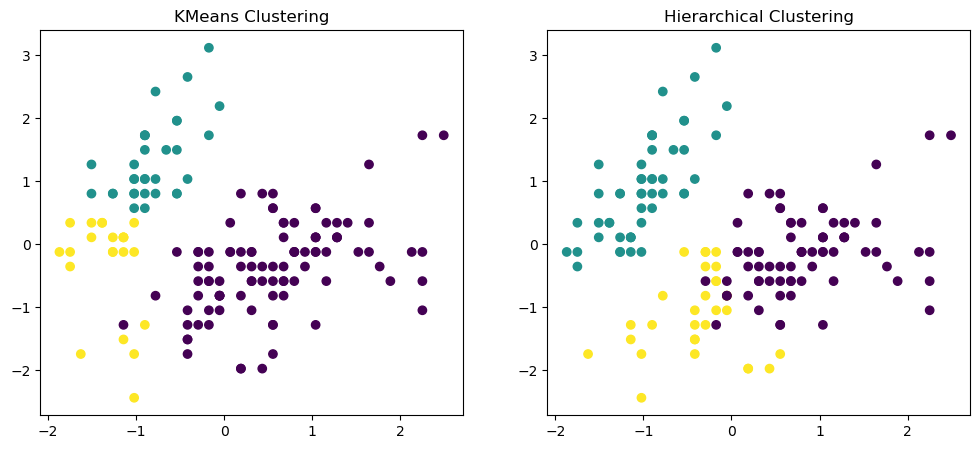

In [14]:
plt.figure(figsize=(12,5))

# KMeans
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("KMeans Clustering")

# Hierarchical
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=h_labels)
plt.title("Hierarchical Clustering")

plt.show()